In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.model_selection import train_test_split


In [3]:
n_users = 10000

# Static demographic features
age = np.random.randint(18, 71, n_users)
bmi = np.clip(np.random.normal(28, 6, n_users), 16, 50)
smoker = np.random.binomial(1, 0.2, n_users)
sex = np.random.binomial(1, 0.5, n_users)

region = np.random.choice(
    ["northwest", "northeast", "southeast", "southwest"],
    size=n_users
)

# Baseline medical cost
epsilon = np.random.normal(0, 2500, n_users)

base_cost = (
    2000
    + 120 * (age - 18)
    + 45 * (bmi - 25) ** 2
    + 9000 * smoker
    + epsilon
)

base_cost = np.clip(base_cost, 1000, None)

users_df = pd.DataFrame({
    "user_id": np.arange(1, n_users + 1),
    "age": age,
    "bmi": bmi,
    "smoker": smoker,
    "sex": sex,
    "region": region,
    "base_cost": base_cost
})

users_df.head()


,user_id,age,bmi,smoker,sex,region,base_cost
0,1,68,34.153111,0,1,southwest,15562.204851
1,2,32,32.737586,0,1,northwest,4854.113199
2,3,55,37.173115,0,1,southwest,11987.909096
3,4,49,28.868029,0,0,southwest,8213.074258
4,5,36,28.557936,0,1,northwest,3451.939007


In [4]:
n_days = 90
dates = pd.date_range(start="2023-01-01", periods=n_days)

# Expand users × days
temporal_df = users_df.loc[users_df.index.repeat(n_days)].copy()
temporal_df["day"] = np.tile(dates, n_users)

temporal_df.reset_index(drop=True, inplace=True)

temporal_df.head()

,user_id,age,bmi,smoker,sex,region,base_cost,day
0,1,68,34.153111,0,1,southwest,15562.204851,2023-01-01
1,1,68,34.153111,0,1,southwest,15562.204851,2023-01-02
2,1,68,34.153111,0,1,southwest,15562.204851,2023-01-03
3,1,68,34.153111,0,1,southwest,15562.204851,2023-01-04
4,1,68,34.153111,0,1,southwest,15562.204851,2023-01-05


In [5]:
temporal_df.shape

(900000, 8)

In [6]:
# User-level financial personality
lambda_txn = np.random.uniform(1.5, 5, n_users)
spend_scale = np.random.uniform(0.8, 1.2, n_users)

temporal_df["lambda_txn"] = np.repeat(lambda_txn, n_days)
temporal_df["spend_scale"] = np.repeat(spend_scale, n_days)

# Daily transaction count (Poisson)
temporal_df["txn_count"] = np.random.poisson(
    temporal_df["lambda_txn"]
)

# Approximate daily spend (vectorized)
# Instead of generating each transaction, we approximate:
# txn_count × lognormal average

lognormal_spend = np.random.lognormal(mean=3.5, sigma=1, size=len(temporal_df))

temporal_df["daily_spend"] = (
    temporal_df["txn_count"] * lognormal_spend * temporal_df["spend_scale"]
)

temporal_df["daily_spend"].describe()

count    900000.000000
mean        177.118327
std         302.368461
min           0.000000
25%          35.456573
50%          87.655292
75%         201.485375
max       34168.801606
Name: daily_spend, dtype: float64

In [7]:
# Normalize daily spend for stress modeling
spend_mean = temporal_df["daily_spend"].mean()
spend_std = temporal_df["daily_spend"].std()

temporal_df["daily_spend_norm"] = (
    (temporal_df["daily_spend"] - spend_mean) / spend_std
)

# Stress influenced by financial instability
stress_noise = np.random.normal(0, 0.5, len(temporal_df))

temporal_df["stress"] = (
    0.4 * temporal_df["daily_spend_norm"] + stress_noise
)

# Baseline heart rate per user
base_hr = np.random.normal(72, 8, n_users)
temporal_df["base_hr"] = np.repeat(base_hr, n_days)

# Heart rate influenced by stress
hr_noise = np.random.normal(0, 2, len(temporal_df))

temporal_df["heart_rate"] = (
    temporal_df["base_hr"] + 0.6 * temporal_df["stress"] + hr_noise
)

temporal_df[["stress", "heart_rate"]].describe()

,stress,heart_rate
count,900000.000000,900000.000000
mean,-0.000507,72.131775
std,0.640863,8.239523
min,-2.454934,35.806464
25%,-0.405487,66.541903
50%,-0.040521,72.130842
75%,0.344687,77.697704
max,44.925654,110.776794


In [8]:
# Sigmoid function
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

# Abnormal probability influenced by stress
prob_abnormal = sigmoid(0.8 * temporal_df["stress"])

temporal_df["lab_abnormal"] = np.random.binomial(1, prob_abnormal)

temporal_df["lab_abnormal"].mean()

np.float64(0.4979388888888889)

In [9]:
temporal_df = temporal_df.sort_values(["user_id", "day"])

# Set multi-index for rolling
temporal_df.set_index(["user_id", "day"], inplace=True)

temporal_df.head()

age        bmi  smoker  sex     region     base_cost  \
user_id day                                                                
1       2023-01-01   68  34.153111       0    1  southwest  15562.204851   
        2023-01-02   68  34.153111       0    1  southwest  15562.204851   
        2023-01-03   68  34.153111       0    1  southwest  15562.204851   
        2023-01-04   68  34.153111       0    1  southwest  15562.204851   
        2023-01-05   68  34.153111       0    1  southwest  15562.204851   

                    lambda_txn  spend_scale  txn_count  daily_spend  \
user_id day                                                           
1       2023-01-01    2.268551     0.903962          1    20.627502   
        2023-01-02    2.268551     0.903962          0     0.000000   
        2023-01-03    2.268551     0.903962          3    36.938661   
        2023-01-04    2.268551     0.903962          3    49.561719   
        2023-01-05    2.268551     0.903962          4    92.613265   

                    daily_spend_norm    stress    base_hr  heart_rate  \
user_id day                                                             
1       2023-01-01         -0.517550  0.133355  87.570895   88.386495   
        2023-01-02         -0.585770 -0.944407  87.570895   86.766512   
        2023-01-03         -0.463605 -0.213349  87.570895   85.449274   
        2023-01-04         -0.421858  0.232236  87.570895   84.996564   
        2023-01-05         -0.279477 -0.071829  87.570895   89.487386   

                    lab_abnormal  
user_id day                       
1       2023-01-01             1  
        2023-01-02             0  
        2023-01-03             0  
        2023-01-04             0  
        2023-01-05             0

In [10]:
# Reset index temporarily for rolling operations
temporal_df = temporal_df.reset_index()

# Group by user
grouped = temporal_df.groupby("user_id")

# Rolling 7-day
temporal_df["spend_vol_7"] = grouped["daily_spend"].rolling(7).std().reset_index(level=0, drop=True)
temporal_df["hr_var_7"] = grouped["heart_rate"].rolling(7).std().reset_index(level=0, drop=True)
temporal_df["abnormal_rate_7"] = grouped["lab_abnormal"].rolling(7).mean().reset_index(level=0, drop=True)

# Rolling 30-day
temporal_df["spend_vol_30"] = grouped["daily_spend"].rolling(30).std().reset_index(level=0, drop=True)
temporal_df["hr_var_30"] = grouped["heart_rate"].rolling(30).std().reset_index(level=0, drop=True)
temporal_df["abnormal_rate_30"] = grouped["lab_abnormal"].rolling(30).mean().reset_index(level=0, drop=True)

# Rolling 90-day
temporal_df["spend_vol_90"] = grouped["daily_spend"].rolling(90).std().reset_index(level=0, drop=True)
temporal_df["hr_var_90"] = grouped["heart_rate"].rolling(90).std().reset_index(level=0, drop=True)
temporal_df["abnormal_rate_90"] = grouped["lab_abnormal"].rolling(90).mean().reset_index(level=0, drop=True)

temporal_df.head()

,user_id,day,age,bmi,smoker,sex,region,base_cost,lambda_txn,spend_scale,...,lab_abnormal,spend_vol_7,hr_var_7,abnormal_rate_7,spend_vol_30,hr_var_30,abnormal_rate_30,spend_vol_90,hr_var_90,abnormal_rate_90
0,1,2023-01-01,68,34.153111,0,1,southwest,15562.204851,2.268551,0.903962,...,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1,2023-01-02,68,34.153111,0,1,southwest,15562.204851,2.268551,0.903962,...,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1,2023-01-03,68,34.153111,0,1,southwest,15562.204851,2.268551,0.903962,...,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,1,2023-01-04,68,34.153111,0,1,southwest,15562.204851,2.268551,0.903962,...,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,1,2023-01-05,68,34.153111,0,1,southwest,15562.204851,2.268551,0.903962,...,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [11]:
# Sort by user and date
temporal_df = temporal_df.sort_values(["user_id", "day"])

# Take last available day per user (this contains full 90-day window)
final_snapshot = temporal_df.groupby("user_id").tail(1).copy()

print("Snapshot shape:", final_snapshot.shape)

# Check NaNs in rolling columns
print(
    final_snapshot[[
        "spend_vol_7",
        "spend_vol_30",
        "spend_vol_90"
    ]].isna().sum()
)

Snapshot shape: (10000, 26)
spend_vol_7     0
spend_vol_30    0
spend_vol_90    0
dtype: int64


In [12]:
def normalize_components(df, prefix):
    for col in [f"spend_vol_{prefix}", f"hr_var_{prefix}", f"abnormal_rate_{prefix}"]:
        df[col + "_norm"] = (
            (df[col] - df[col].mean()) / df[col].std()
        )
    return df

final_7 = normalize_components(final_snapshot.copy(), 7)
final_30 = normalize_components(final_snapshot.copy(), 30)
final_90 = normalize_components(final_snapshot.copy(), 90)

In [13]:
# Theoretical weighted HFS
final_7["HFS_7"] = (
    0.4 * final_7["hr_var_7_norm"] +
    0.35 * final_7["spend_vol_7_norm"] +
    0.25 * final_7["abnormal_rate_7_norm"]
)

final_30["HFS_30"] = (
    0.4 * final_30["hr_var_30_norm"] +
    0.35 * final_30["spend_vol_30_norm"] +
    0.25 * final_30["abnormal_rate_30_norm"]
)

final_90["HFS_90"] = (
    0.4 * final_90["hr_var_90_norm"] +
    0.35 * final_90["spend_vol_90_norm"] +
    0.25 * final_90["abnormal_rate_90_norm"]
)

final_90[["HFS_90"]].describe()

,HFS_90
count,1.000000e+04
mean,-3.570477e-16
std,6.476171e-01
min,-1.793836e+00
25%,-4.215660e-01
50%,-3.928564e-02
75%,3.663202e-01
max,1.246153e+01


In [15]:
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

In [16]:
def evaluate_models(df, window_label):
    
    features_base = ["age", "bmi", "smoker", "base_cost"]
    features_hfs = features_base + [f"HFS_{window_label}"]
    
    X_base = df[features_base]
    X_hfs = df[features_hfs]
    y = df["final_cost"]
    
    Xb_train, Xb_test, y_train, y_test = train_test_split(
        X_base, y, test_size=0.2, random_state=42
    )
    
    Xh_train, Xh_test, _, _ = train_test_split(
        X_hfs, y, test_size=0.2, random_state=42
    )
    
    models = {
        "RandomForest": RandomForestRegressor(n_estimators=200, random_state=42),
        "XGBoost": XGBRegressor(n_estimators=300, random_state=42, verbosity=0),
        "LightGBM": LGBMRegressor(n_estimators=300, random_state=42)
    }
    
    results = []
    
    for name, model in models.items():
        
        # Baseline
        model.fit(Xb_train, y_train)
        pred_base = model.predict(Xb_test)
        
        r2_base = r2_score(y_test, pred_base)
        mae_base = mean_absolute_error(y_test, pred_base)
        rmse_base = np.sqrt(mean_squared_error(y_test, pred_base))
        
        # With HFS
        model.fit(Xh_train, y_train)
        pred_hfs = model.predict(Xh_test)
        
        r2_hfs = r2_score(y_test, pred_hfs)
        mae_hfs = mean_absolute_error(y_test, pred_hfs)
        rmse_hfs = np.sqrt(mean_squared_error(y_test, pred_hfs))
        
        spg = (r2_hfs - r2_base) / (1 - r2_base)
        
        results.append({
            "Window": window_label,
            "Model": name,
            "R2_Base": r2_base,
            "R2_HFS": r2_hfs,
            "MAE_Base": mae_base,
            "MAE_HFS": mae_hfs,
            "RMSE_Base": rmse_base,
            "RMSE_HFS": rmse_hfs,
            "SPG": spg
        })
    
    return pd.DataFrame(results)

In [18]:
import seaborn as sns

In [24]:
print("Correlation Matrix (90-Day):")
print(
    final_90[[
        "HFS_90",
        "spend_vol_90",
        "hr_var_90",
        "abnormal_rate_90"
    ]].corr()
)

Correlation Matrix (90-Day):
                    HFS_90  spend_vol_90  hr_var_90  abnormal_rate_90
HFS_90            1.000000      0.704394   0.697447          0.488400
spend_vol_90      0.704394      1.000000   0.147356          0.188942
hr_var_90         0.697447      0.147356   1.000000          0.000417
abnormal_rate_90  0.488400      0.188942   0.000417          1.000000


corrected->

In [29]:
# Compute raw health shock
raw_shock = (
    1400 * final_90["abnormal_rate_90"] +
    800  * final_90["hr_var_90"] +
    500  * final_90["spend_vol_90"]
)

# Scale it relative to base cost variance
scale_factor = 0.5 * final_90["base_cost"].std() / raw_shock.std()

health_shock_90 = raw_shock * scale_factor + np.random.normal(0, 1200, len(final_90))

final_90["final_cost"] = final_90["base_cost"] + health_shock_90
final_90["final_cost"] = final_90["final_cost"].clip(lower=1000)

In [30]:
results_90_new = evaluate_models(final_90, 90)
results_90_new

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000377 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 566
[LightGBM] [Info] Number of data points in the train set: 8000, number of used features: 4
[LightGBM] [Info] Start training from score 14114.911322
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000093 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 821
[LightGBM] [Info] Number of data points in the train set: 8000, number of used features: 5
[LightGBM] [Info] Start training from score 14114.911322


,Window,Model,R2_Base,R2_HFS,MAE_Base,MAE_HFS,RMSE_Base,RMSE_HFS,SPG
0,90,RandomForest,0.724079,0.846034,2288.931499,1777.989481,3195.279932,2386.873729,0.441991
1,90,XGBoost,0.681899,0.811387,2471.658101,1913.972765,3430.831038,2641.812037,0.407068
2,90,LightGBM,0.731004,0.843912,2257.098934,1801.695852,3154.927750,2403.266271,0.419737


In [31]:
features_hfs = ["age", "bmi", "smoker", "base_cost", "HFS_90"]

X = final_90[features_hfs]
y = final_90["final_cost"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

rf = RandomForestRegressor(n_estimators=300, random_state=42)
rf.fit(X_train, y_train)

for feat, imp in zip(features_hfs, rf.feature_importances_):
    print(feat, round(imp,4))

age 0.0233
bmi 0.0283
smoker 0.001
base_cost 0.8054
HFS_90 0.1421


In [32]:
# --- 7-Day Variance-Scaled Final Cost ---

raw_shock_7 = (
    1200 * final_7["abnormal_rate_7"] +
    700  * final_7["hr_var_7"] +
    450  * final_7["spend_vol_7"]
)

scale_factor_7 = 0.5 * final_7["base_cost"].std() / raw_shock_7.std()

health_shock_7 = raw_shock_7 * scale_factor_7 + np.random.normal(0, 1000, len(final_7))

final_7["final_cost"] = final_7["base_cost"] + health_shock_7
final_7["final_cost"] = final_7["final_cost"].clip(lower=1000)

final_7["final_cost"].describe()

count    10000.000000
mean     11628.909549
std       6051.025244
min       1000.000000
25%       7274.421463
50%      10691.240827
75%      15255.034404
max      70905.494510
Name: final_cost, dtype: float64

In [33]:
# --- 30-Day Variance-Scaled Final Cost ---

raw_shock_30 = (
    1300 * final_30["abnormal_rate_30"] +
    750  * final_30["hr_var_30"] +
    500  * final_30["spend_vol_30"]
)

scale_factor_30 = 0.5 * final_30["base_cost"].std() / raw_shock_30.std()

health_shock_30 = raw_shock_30 * scale_factor_30 + np.random.normal(0, 1100, len(final_30))

final_30["final_cost"] = final_30["base_cost"] + health_shock_30
final_30["final_cost"] = final_30["final_cost"].clip(lower=1000)

final_30["final_cost"].describe()

count    10000.000000
mean     13099.202768
std       6050.440050
min       1000.000000
25%       8715.912386
50%      12148.509348
75%      16814.589951
max      51240.839276
Name: final_cost, dtype: float64

In [34]:
results_7_new = evaluate_models(final_7, 7)
results_30_new = evaluate_models(final_30, 30)

results_all_new = pd.concat([results_7_new, results_30_new, results_90_new]).reset_index(drop=True)

results_all_new

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.003328 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 566
[LightGBM] [Info] Number of data points in the train set: 8000, number of used features: 4
[LightGBM] [Info] Start training from score 11644.979577
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000105 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 821
[LightGBM] [Info] Number of data points in the train set: 8000, number of used features: 5
[LightGBM] [Info] Start training from score 11644.979577
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.002081 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 566
[LightGBM] [Info] Number of data points in the train se

,Window,Model,R2_Base,R2_HFS,MAE_Base,MAE_HFS,RMSE_Base,RMSE_HFS,SPG
0,7,RandomForest,0.722712,0.865350,2025.615563,1581.768384,3210.073903,2236.932152,0.514403
1,7,XGBoost,0.648522,0.834542,2220.125540,1700.418724,3614.087519,2479.668970,0.529250
2,7,LightGBM,0.731589,0.872149,1979.244784,1547.123181,3158.273343,2179.723430,0.523675
3,30,RandomForest,0.735898,0.855447,2254.985855,1750.989840,3085.381600,2282.640120,0.452660
4,30,XGBoost,0.684171,0.831350,2436.172215,1864.180919,3374.034208,2465.562284,0.466010
5,30,LightGBM,0.747061,0.854697,2195.922746,1753.748040,3019.475393,2288.551444,0.425542
6,90,RandomForest,0.724079,0.846034,2288.931499,1777.989481,3195.279932,2386.873729,0.441991
7,90,XGBoost,0.681899,0.811387,2471.658101,1913.972765,3430.831038,2641.812037,0.407068
8,90,LightGBM,0.731004,0.843912,2257.098934,1801.695852,3154.927750,2403.266271,0.419737


In [35]:
final_results = results_all_new.copy()
final_results

,Window,Model,R2_Base,R2_HFS,MAE_Base,MAE_HFS,RMSE_Base,RMSE_HFS,SPG
0,7,RandomForest,0.722712,0.865350,2025.615563,1581.768384,3210.073903,2236.932152,0.514403
1,7,XGBoost,0.648522,0.834542,2220.125540,1700.418724,3614.087519,2479.668970,0.529250
2,7,LightGBM,0.731589,0.872149,1979.244784,1547.123181,3158.273343,2179.723430,0.523675
3,30,RandomForest,0.735898,0.855447,2254.985855,1750.989840,3085.381600,2282.640120,0.452660
4,30,XGBoost,0.684171,0.831350,2436.172215,1864.180919,3374.034208,2465.562284,0.466010
5,30,LightGBM,0.747061,0.854697,2195.922746,1753.748040,3019.475393,2288.551444,0.425542
6,90,RandomForest,0.724079,0.846034,2288.931499,1777.989481,3195.279932,2386.873729,0.441991
7,90,XGBoost,0.681899,0.811387,2471.658101,1913.972765,3430.831038,2641.812037,0.407068
8,90,LightGBM,0.731004,0.843912,2257.098934,1801.695852,3154.927750,2403.266271,0.419737


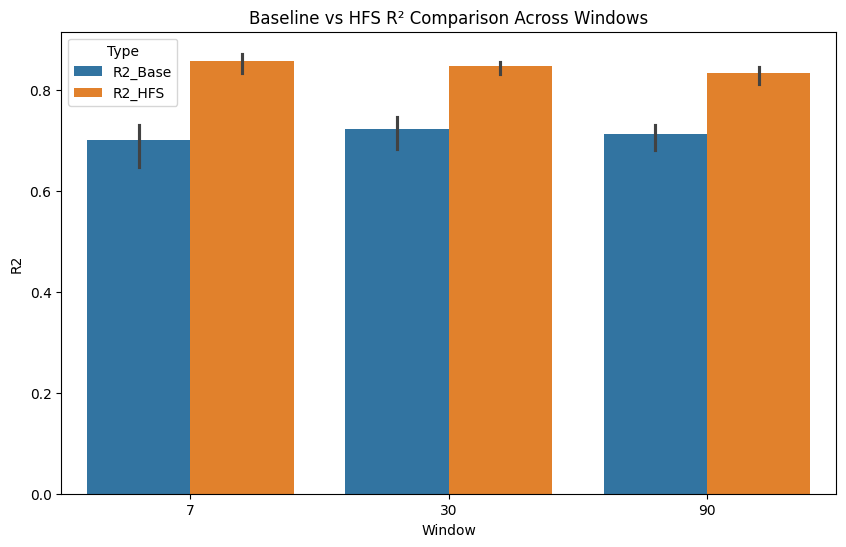

In [36]:
plt.figure(figsize=(10,6))

melted = final_results.melt(
    id_vars=["Window","Model"],
    value_vars=["R2_Base","R2_HFS"],
    var_name="Type",
    value_name="R2"
)

sns.barplot(data=melted, x="Window", y="R2", hue="Type")
plt.title("Baseline vs HFS R² Comparison Across Windows")
plt.show()

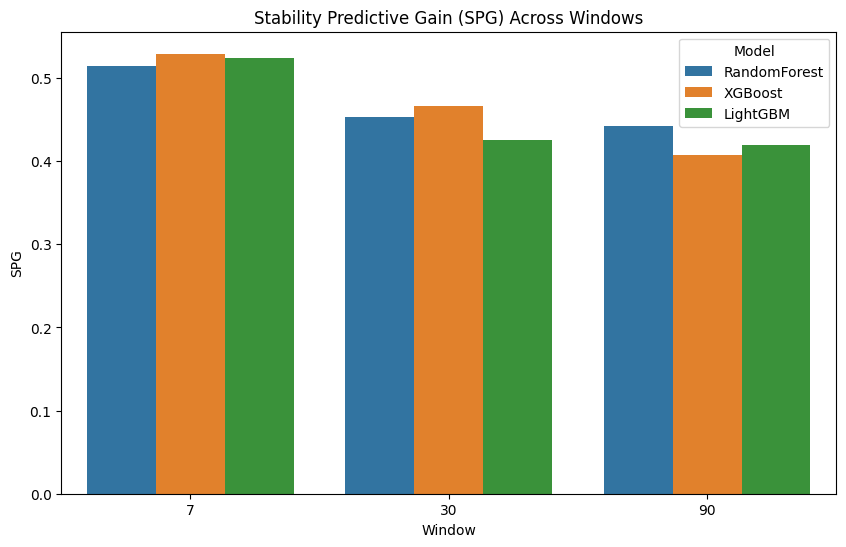

In [37]:
plt.figure(figsize=(10,6))
sns.barplot(data=final_results, x="Window", y="SPG", hue="Model")
plt.title("Stability Predictive Gain (SPG) Across Windows")
plt.show()

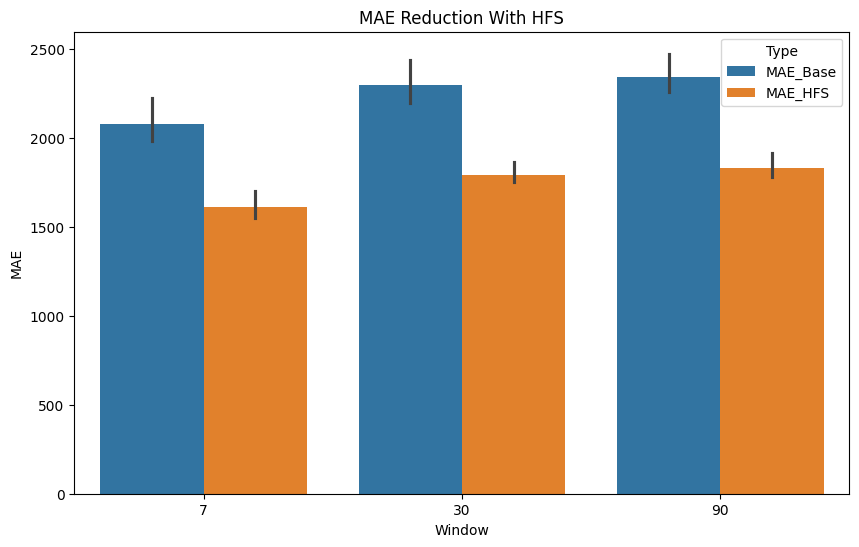

In [38]:
plt.figure(figsize=(10,6))

mae_melted = final_results.melt(
    id_vars=["Window","Model"],
    value_vars=["MAE_Base","MAE_HFS"],
    var_name="Type",
    value_name="MAE"
)

sns.barplot(data=mae_melted, x="Window", y="MAE", hue="Type")
plt.title("MAE Reduction With HFS")
plt.show()

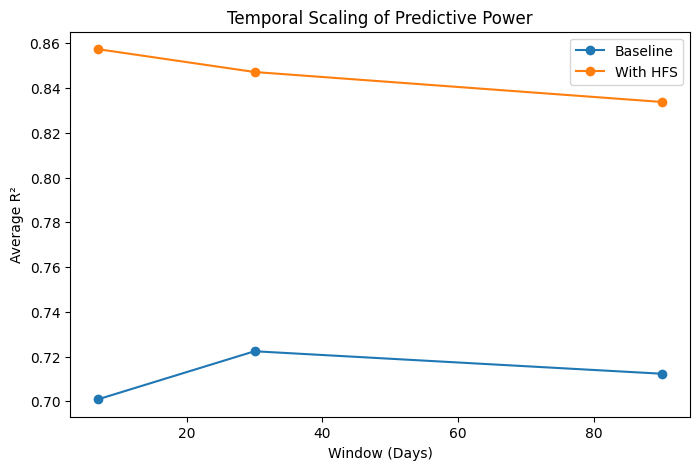

In [39]:
avg_r2 = final_results.groupby("Window")[["R2_Base","R2_HFS"]].mean().reset_index()

plt.figure(figsize=(8,5))
plt.plot(avg_r2["Window"], avg_r2["R2_Base"], marker='o', label="Baseline")
plt.plot(avg_r2["Window"], avg_r2["R2_HFS"], marker='o', label="With HFS")

plt.title("Temporal Scaling of Predictive Power")
plt.xlabel("Window (Days)")
plt.ylabel("Average R²")
plt.legend()
plt.show()

premium calculation


In [40]:
alphas = np.linspace(0, 0.3, 15)

premium_results = []

for a in alphas:
    premium = final_90["base_cost"] * (1 + a * final_90["HFS_90"])
    
    corr = np.corrcoef(premium, final_90["HFS_90"])[0,1]
    mean_premium = premium.mean()
    std_premium = premium.std()
    
    premium_results.append({
        "alpha": a,
        "correlation": corr,
        "mean_premium": mean_premium,
        "std_premium": std_premium
    })

premium_results = pd.DataFrame(premium_results)
premium_results

,alpha,correlation,mean_premium,std_premium
0,0.000000,-0.011040,8945.289725,5362.406472
1,0.021429,0.012718,8944.468243,5362.579948
2,0.042857,0.036447,8943.646762,5366.826219
3,0.064286,0.060093,8942.825280,5375.135634
4,0.085714,0.083603,8942.003798,5387.489392
5,0.107143,0.106926,8941.182316,5403.859756
6,0.128571,0.130012,8940.360834,5424.210359
7,0.150000,0.152816,8939.539352,5448.496602
8,0.171429,0.175293,8938.717870,5476.666127
9,0.192857,0.197402,8937.896388,5508.659362


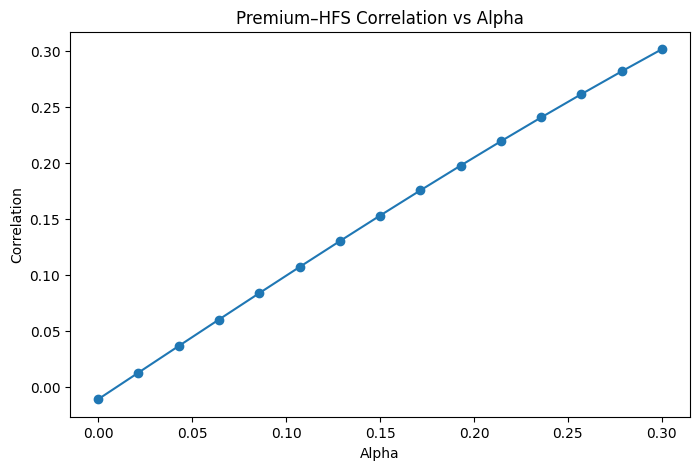

In [41]:
plt.figure(figsize=(8,5))
plt.plot(premium_results["alpha"], premium_results["correlation"], marker='o')
plt.title("Premium–HFS Correlation vs Alpha")
plt.xlabel("Alpha")
plt.ylabel("Correlation")
plt.show()

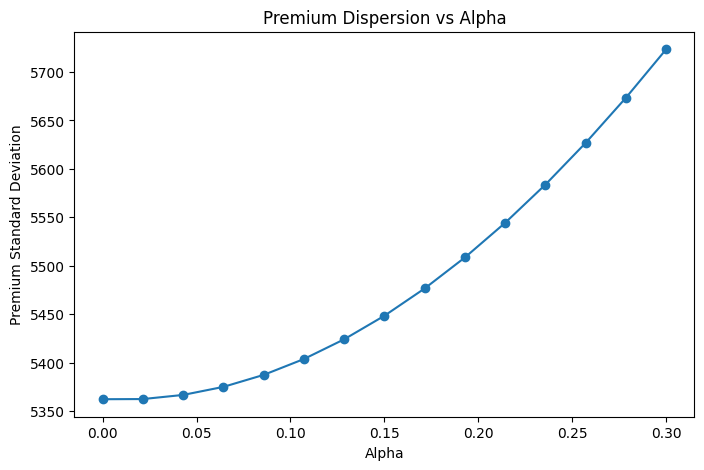

In [42]:
plt.figure(figsize=(8,5))
plt.plot(premium_results["alpha"], premium_results["std_premium"], marker='o')
plt.title("Premium Dispersion vs Alpha")
plt.xlabel("Alpha")
plt.ylabel("Premium Standard Deviation")
plt.show()

In [43]:
final_90["risk_tier"] = pd.cut(
    final_90["HFS_90"],
    bins=[-np.inf, -0.5, 0.5, np.inf],
    labels=["Low","Medium","High"]
)

alpha_test = 0.15
final_90["premium_alpha"] = final_90["base_cost"] * (1 + alpha_test * final_90["HFS_90"])

tier_summary = final_90.groupby("risk_tier")["premium_alpha"].mean().reset_index()
tier_summary

/tmp/ipykernel_55/202350583.py:10: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  tier_summary = final_90.groupby("risk_tier")["premium_alpha"].mean().reset_index()


,risk_tier,premium_alpha
0,Low,8127.386296
1,Medium,8806.659332
2,High,10271.755718


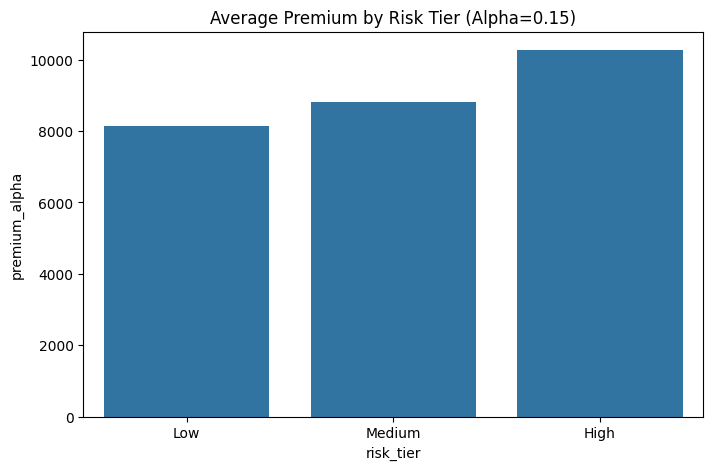

In [44]:
plt.figure(figsize=(8,5))
sns.barplot(data=tier_summary, x="risk_tier", y="premium_alpha")
plt.title("Average Premium by Risk Tier (Alpha=0.15)")
plt.show()

In [45]:
# Aggregate summary for manuscript

summary_table = final_results.groupby("Window").agg({
    "R2_Base": ["mean", "std"],
    "R2_HFS": ["mean", "std"],
    "SPG": ["mean", "std"],
    "MAE_Base": "mean",
    "MAE_HFS": "mean",
    "RMSE_Base": "mean",
    "RMSE_HFS": "mean"
}).reset_index()

summary_table

Window   R2_Base              R2_HFS                 SPG            \
              mean       std      mean       std      mean       std   
0      7  0.700941  0.045613  0.857347  0.020040  0.522443  0.007500   
1     30  0.722377  0.033555  0.847165  0.013701  0.448071  0.020621   
2     90  0.712327  0.026578  0.833777  0.019419  0.422932  0.017680   

      MAE_Base      MAE_HFS    RMSE_Base     RMSE_HFS  
          mean         mean         mean         mean  
0  2074.995295  1609.770096  3327.478255  2298.774851  
1  2295.693605  1789.639600  3159.630401  2345.584616  
2  2339.229512  1831.219366  3260.346240  2477.317345

In [46]:
summary_table.columns = [
    "Window",
    "R2_Base_Mean", "R2_Base_STD",
    "R2_HFS_Mean", "R2_HFS_STD",
    "SPG_Mean", "SPG_STD",
    "MAE_Base_Mean",
    "MAE_HFS_Mean",
    "RMSE_Base_Mean",
    "RMSE_HFS_Mean"
]

summary_table

,Window,R2_Base_Mean,R2_Base_STD,R2_HFS_Mean,R2_HFS_STD,SPG_Mean,SPG_STD,MAE_Base_Mean,MAE_HFS_Mean,RMSE_Base_Mean,RMSE_HFS_Mean
0,7,0.700941,0.045613,0.857347,0.020040,0.522443,0.007500,2074.995295,1609.770096,3327.478255,2298.774851
1,30,0.722377,0.033555,0.847165,0.013701,0.448071,0.020621,2295.693605,1789.639600,3159.630401,2345.584616
2,90,0.712327,0.026578,0.833777,0.019419,0.422932,0.017680,2339.229512,1831.219366,3260.346240,2477.317345


In [47]:
summary_table_rounded = summary_table.round(4)
summary_table_rounded

,Window,R2_Base_Mean,R2_Base_STD,R2_HFS_Mean,R2_HFS_STD,SPG_Mean,SPG_STD,MAE_Base_Mean,MAE_HFS_Mean,RMSE_Base_Mean,RMSE_HFS_Mean
0,7,0.7009,0.0456,0.8573,0.0200,0.5224,0.0075,2074.9953,1609.7701,3327.4783,2298.7749
1,30,0.7224,0.0336,0.8472,0.0137,0.4481,0.0206,2295.6936,1789.6396,3159.6304,2345.5846
2,90,0.7123,0.0266,0.8338,0.0194,0.4229,0.0177,2339.2295,1831.2194,3260.3462,2477.3173


In [49]:
summary_table_rounded.to_csv("final_results_summary.csv", index=False)

In [51]:
final_7[["user_id","age","bmi","smoker","base_cost","HFS_7"]].to_csv("batch_7_final_updated.csv", index=False)
final_30[["user_id","age","bmi","smoker","base_cost","HFS_30"]].to_csv("batch_30_final_updated.csv", index=False)
final_90[["user_id","age","bmi","smoker","base_cost","HFS_90"]].to_csv("batch_90_final_updated.csv", index=False)